In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
import pygmsh 

In [72]:
#Estracción de datos físicos
datos = pd.read_csv('properties_dataNonDim.csv')
theta = datos['T_params']
alpha = datos[' C_nondim_curve']
kappa = datos[' K_nondim_curve']

<function matplotlib.pyplot.show(close=None, block=None)>

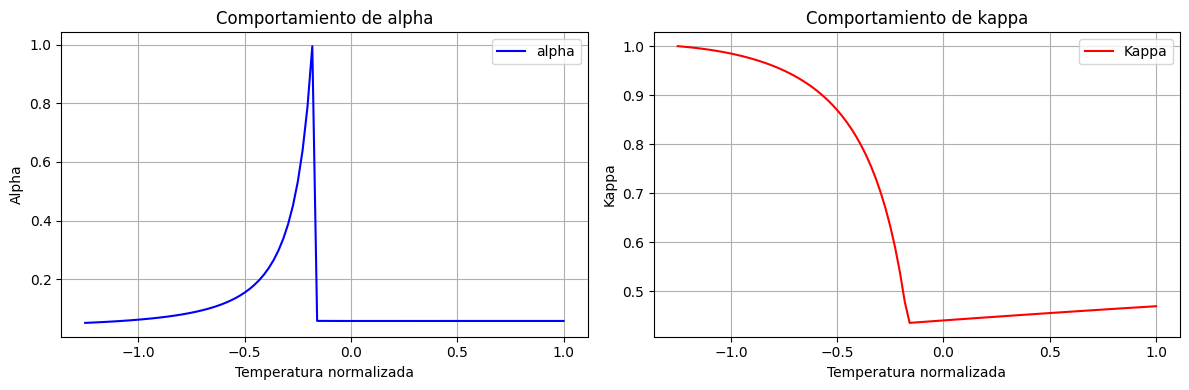

In [73]:
#Graficas de los parámetros físicos
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12, 4))

ax1.plot(theta, alpha, color = 'blue', label = 'alpha')
ax1.set_title('Comportamiento de alpha')
ax1.set_xlabel('Temperatura normalizada')
ax1.set_ylabel('Alpha')
ax1.grid(True)
ax1.legend()

ax2.plot(theta, kappa, color = 'red', label = 'Kappa')
ax2.set_title('Comportamiento de kappa')
ax2.set_xlabel('Temperatura normalizada')
ax2.set_ylabel('Kappa')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show

In [74]:
#Interpoladores
f_alpha = interp1d(theta, alpha, kind = 'cubic', )
f_kappa = interp1d(theta, kappa, kind = 'cubic')

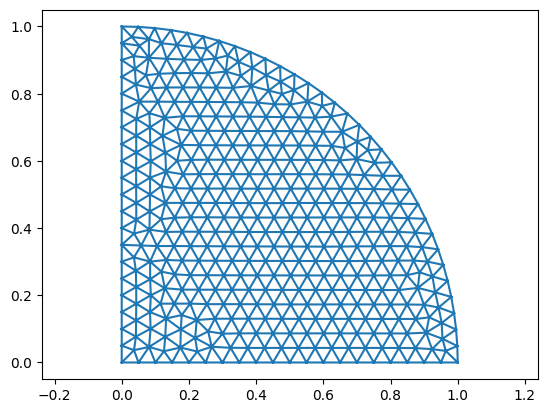

In [75]:
#Generación de mallas, lc controla el refinamiento
lc = 0.05
with pygmsh.geo.Geometry() as geom:
    p0 = geom.add_point([0.0, 0.0, 0.0], mesh_size = lc)
    p1 = geom.add_point([1.0, 0.0, 0.0], mesh_size = lc)
    p2 = geom.add_point([0.0, 1.0, 0.0], mesh_size = lc)
    l1 = geom.add_line(p0, p1)
    l2 = geom.add_circle_arc(p1, p0, p2)
    geom.add_physical(l2, label='frontera')
    l3 = geom.add_line(p2, p0)
    contorno = geom.add_curve_loop([l1, l2, l3])
    superficie = geom.add_plane_surface(contorno)
    malla = geom.generate_mesh()
    pass
nodos = malla.points[:, 0:2]
elementos = malla.cells_dict['triangle']
x_coor = nodos[:, 0]
y_coor = nodos[:, 1]
plt.triplot(x_coor, y_coor, elementos)
plt.axis('equal')
plt.show()



In [76]:
#Generar las matrices locales

def calcular_matrices_locales(v0, v1,v2 , theta_elem):
    x0, y0 = v0[0], v0[1]
    x1, y1 = v1[0], v1[1]
    x2, y2 = v2[0], v2[1]

    J = np.array([[x1 - x0, x2 - x0],
                  [y1 - y0, y2 - y0]],
                )
    
    invJ = np.linalg.inv(J)

    D = np.array([[-1, 1, 0],
                  [-1, 0, 1]])
    
    detJ = np.abs((x1 - x0) * (y2 - y0) - (x2 - x0) * (y1 - y0))

    alpha_elem = f_alpha(theta_elem)
    kappa_elem = f_kappa(theta_elem)

    K_local = kappa_elem * ( detJ / 2 )*(invJ @ D).T @ (invJ @ D)
    M_local = alpha_elem * ( detJ / 24) * np.array([[2,1,1],[1,2,1],[1,1,2]])

    return M_local, K_local

In [77]:
#Ensamblaje de matrices globales


def ensablaje_matrices_globales(nodos, elementos, theta_n):
    num_nodos = len(nodos)
    M_global = np.zeros((num_nodos, num_nodos))
    K_global = np.zeros((num_nodos, num_nodos))
    for elemento in elementos:
        v0 = nodos[elemento[0]]
        v1 = nodos[elemento[1]]
        v2 = nodos[elemento[2]]

        theta_elem = np.mean(theta_n[elemento])

        M_local, K_local = calcular_matrices_locales(v0, v1, v2, theta_elem)

        for i in range(3):
            for j in range(3):
                M_global[elemento[i], elemento[j]] += M_local[i, j]
                K_global[elemento[i], elemento[j]] += K_local[i, j]
                
    return M_global, K_global 


In [78]:
#Extracción de nodos en la frontera
indices_lineas = malla.cell_sets_dict['frontera']['line']
lineas_curvas = malla.cells_dict['line'][indices_lineas]
nodos_frontera = np.unique(lineas_curvas)

w_n = 2.25 * np.ones(len(nodos)) #Variable de temperatura auxiliar inicial
for n in nodos_frontera:
    w_n[n] = 0

nodos_todos = np.arange(len(nodos))
nodos_interiores = np.setdiff1d(nodos_todos, nodos_frontera)

In [79]:
#Solución del sistema:
pasos_tiempo = 2000
delta_tau = 0.00001
for pasos in range(pasos_tiempo):
    theta_actual = np.clip(w_n - 1.25, 0.0, 1.0)
    M_global, K_global = ensablaje_matrices_globales(nodos, elementos, theta_actual)

    M_int = M_global[np.ix_(nodos_interiores, nodos_interiores)]
    K_int = K_global[np.ix_(nodos_interiores, nodos_interiores)]
    w_int = w_n[nodos_interiores]

    b_int = (M_int- delta_tau*K_int) @ w_int
    w_nuevo = np.linalg.solve(M_int, b_int)
    w_int = w_nuevo
    w_n[nodos_interiores] = w_nuevo

theta_final = w_n - 1.25

theta_final


array([-1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -0.11099598, -0.11528729,
       -0.11966302, -0.14047344, -0.15076545, -0.19764624, -0.2163579 ,
       -0.29064114, -0.35059786, -0.38721331, -0.48798712, -0.5400399 ,
       -0.65043405, -0.70583052, -0.81615513, -0.89735302, -0.94127473,
       -1.05519087, -1.10908863, -1.17679145, -1.17630757, -1.10049964,
       -1.019426  , -0.94033669, -0.84223081, -0.76127907, -0.67026438,
       -0.58424344, -0.5169339 , -0.44904495, -0.39274039, -0.32387615,
       -0.26953318, -0.23312349, -0.195407  , -0.16793935, -0.14

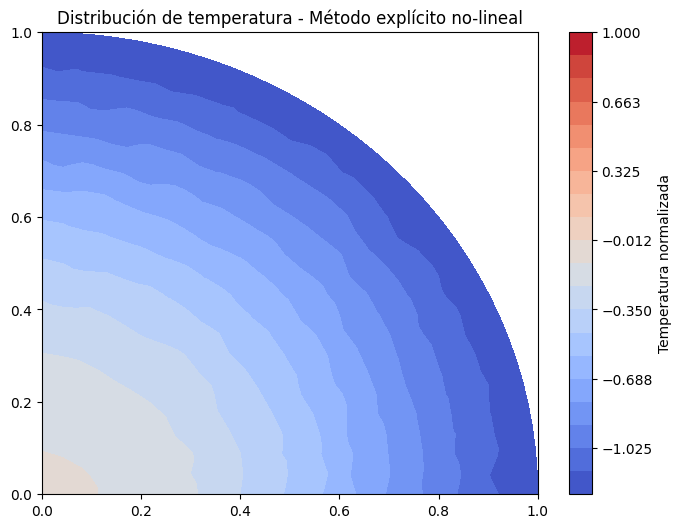

In [80]:
#Grafica de la solución:

limite_inferior = -1.25  
limite_superior = 1.0   
niveles_fijos = np.linspace(limite_inferior, limite_superior, 21)

plt.figure(figsize=(8,6))
plt.title('Distribución de temperatura - Método explícito no-lineal')
grafico = plt.tricontourf(x_coor, y_coor, elementos, theta_final, levels=niveles_fijos, cmap='coolwarm') 
plt.colorbar(grafico, label='Temperatura normalizada')
plt.show()